# Big Data Analytics Project
**Author:** Fatima Aghapourasl

### 1. Introduction and Loading Data
In this notebook, I will perform Data Aggregation, Feature Engineering, and Exploratory Data Analysis (EDA) to answer my three Research Questions. First, I will load the raw datasets and the necessary Python libraries.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import datetime as dt
import seaborn as sns

In [2]:
# Download data directly from Kaggle (no manual uploads)
from pathlib import Path
import os
import zipfile

DATA_DIR = Path("data/olist")
DATA_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_DATASET = "olistbr/brazilian-ecommerce"
NEEDED = {
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv",
}

def _has_needed_csvs(folder: Path) -> bool:
    present = {p.name for p in folder.rglob("*.csv")}
    return NEEDED.issubset(present)
# Ensure kaggle package/CLI
try:
    import kaggle  # noqa: F401
except Exception:
    print("Installing kaggle...")
    %pip -q install kaggle
# Download from Kaggle if missing
if not _has_needed_csvs(DATA_DIR):
    print(f"Downloading from Kaggle dataset: {KAGGLE_DATASET}")
    exit_code = os.system(f"kaggle datasets download -d {KAGGLE_DATASET} -p '{DATA_DIR}' -q")
    if exit_code != 0:
        raise RuntimeError(
            "Kaggle download failed. Configure kaggle.json (see the next Markdown cell)."
        )

    zip_files = list(DATA_DIR.glob("*.zip"))
    if not zip_files:
        raise FileNotFoundError(f"No .zip found in {DATA_DIR} after Kaggle download.")

    for zpath in zip_files:
        print(f"Unzipping: {zpath.name}")
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(DATA_DIR)

# Load CSVs (robust to nested unzip folders)
def _csv(name: str) -> Path:
    matches = list(DATA_DIR.rglob(name))
    if not matches:
        raise FileNotFoundError(f"Missing {name} under {DATA_DIR}.")
    return matches[0]

orders = pd.read_csv(_csv("olist_orders_dataset.csv"))
items = pd.read_csv(_csv("olist_order_items_dataset.csv"))
payments = pd.read_csv(_csv("olist_order_payments_dataset.csv"))
reviews = pd.read_csv(_csv("olist_order_reviews_dataset.csv"))
customers = pd.read_csv(_csv("olist_customers_dataset.csv"))

print("All datasets loaded successfully!")
print("Data folder:", DATA_DIR.resolve())

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication
Installing kaggle...

[notice] A new release of pip is available: 23.3.1 -> 26.0.1
[notice] To update, run: /Users/Fatemeh/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
All datasets loaded successfully!
Data folder: /Users/Fatemeh/FATEMEH/TMU/capstone project/m3/data/olist


### Kaggle credentials setup (required)

To download directly from Kaggle, you must configure your Kaggle API credentials:

- Create an API token in Kaggle: **Account → API → Create New Token** (downloads `kaggle.json`).
- Place it at: `~/.kaggle/kaggle.json` (Mac/Linux)
- Then set permissions:


## 2. Data Aggregation (Replicating SQL Logic)

To avoid double-counting revenue (since one order can have multiple payment installments or items), I must aggregate one-to-many tables to **one row per `order_id`** before merging into `orders`.

### Review aggregation rule 

The reviews table can contain **multiple rows per `order_id`**. There are two defensible strategies:

- **Average review score per order (chosen for main analysis)**: uses *all available feedback* and produces a stable order-level label.
- **Latest review score per order (kept for sensitivity analysis)**: reflects the final sentiment but can be more sensitive to timing and revisions.

In this notebook I compute **both**:

- `review_score` = mean score per `order_id` (main label used in modeling)
- `review_score_latest` = latest score per `order_id` (secondary)
- `review_count` = number of review records per `order_id` (quality signal)



## 2.1 Why `LEFT JOIN` + how nulls & one-to-many tables are handled (Professor feedback)

In the Olist data model, `orders` is the **fact table** (one row per `order_id`) and the other tables provide **optional attributes**:

- **Why `LEFT JOIN`**: I use `LEFT JOIN` from `orders` to `customers`, `payments_grouped`, and `reviews_grouped` to **preserve the full set of orders** (including orders that may have missing payments/reviews due to data capture issues, cancellations, or timing). Using `INNER JOIN` would silently drop those orders and bias downstream analytics.

- **How I prevented duplicates (join multiplication)**: Raw `payments` and `reviews` are **one-to-many** w.r.t. `order_id`. Joining them directly would multiply rows. To prevent double-counting, I first aggregate:
  - `payments_grouped`: sum of `payment_value` per `order_id` → **one row per order**
  - `reviews_grouped`: mean of `review_score` per `order_id` → **one row per order** (when multiple reviews exist)

- **How I handle nulls introduced by `LEFT JOIN`**:
  - If `total_payment` is null, it indicates **no payment record** matched that order in the raw data; I keep it as missing (and later filter/impute depending on the specific analysis/model).
  - If `review_score` is null, it indicates **no review submitted** for that order; for satisfaction modeling, I explicitly restrict to orders with observed `review_score` (the label).

Immediately below, I validate this design with row counts, duplicate checks on `order_id`, and `merge` indicators to prove the LEFT JOINs did not create duplicates and did not change the row count of the base `orders` table.

In [3]:
# Group payments by order_id so each order has only one total revenue row
payments_grouped = payments.groupby('order_id')['payment_value'].sum().reset_index()
payments_grouped.rename(columns={'payment_value': 'total_payment'}, inplace=True)
# Reviews: compute mean + latest
# Prefer an explicit review timestamp column if present
review_time_col = None
for c in ['review_creation_date', 'review_answer_timestamp']:
    if c in reviews.columns:
        review_time_col = c
        break
reviews_tmp = reviews.copy()
if review_time_col is not None:
    reviews_tmp[review_time_col] = pd.to_datetime(reviews_tmp[review_time_col], errors='coerce')

# Mean review score per order (main)
reviews_mean = (
    reviews_tmp.groupby('order_id', as_index=False)
    .agg(review_score=('review_score', 'mean'), review_count=('review_score', 'size'))
)
# Latest review score per order (sensitivity)
if review_time_col is not None:
    reviews_latest = (
        reviews_tmp.sort_values(review_time_col)
        .drop_duplicates(subset=['order_id'], keep='last')
        [['order_id', 'review_score']]
        .rename(columns={'review_score': 'review_score_latest'})
    )
else:
    # If no timestamp exists, "latest" cannot be reliably determined
    reviews_latest = reviews_mean[['order_id']].assign(review_score_latest=np.nan)

reviews_grouped = reviews_mean.merge(reviews_latest, on='order_id', how='left')
# Now, merge everything to create the 'order_master' table
order_master = pd.merge(orders, customers, on='customer_id', how='left')
order_master = pd.merge(order_master, payments_grouped, on='order_id', how='left')
order_master = pd.merge(order_master, reviews_grouped, on='order_id', how='left')

print("Master table created. Total rows:", len(order_master))
print("Review time column used for latest:", review_time_col)

Master table created. Total rows: 99441
Review time column used for latest: review_creation_date


In [4]:
# Join + aggregation validation
def _dup_summary(df: pd.DataFrame, keys, name: str):
    dups = df.duplicated(subset=keys, keep=False).sum()
    uniq = df[keys].drop_duplicates().shape[0]
    print(f"[{name}] rows={len(df):,} | unique({keys})={uniq:,} | duplicate_rows_on_keys={dups:,}")

def _null_rate(df: pd.DataFrame, cols, name: str):
    s = df[cols].isna().mean().sort_values(ascending=False)
    print(f"\n[{name}] null rate by column")
    display((s * 100).round(2).rename("% null"))

print("=== 0) Base table expectations ===")
_dup_summary(orders, ["order_id"], "orders")
_dup_summary(customers, ["customer_id"], "customers")

print("\n=== 1) Validate pre-aggregation (protect against join-multiplication) ===")
# Payments should be many-to-one on order_id AFTER grouping
_dup_summary(payments, ["order_id"], "payments (raw)")
_dup_summary(payments_grouped, ["order_id"], "payments_grouped")
assert payments_grouped["order_id"].is_unique, "payments_grouped is not 1 row per order_id"

# Reviews should be many-to-one on order_id AFTER grouping
_dup_summary(reviews, ["order_id"], "reviews (raw)")
_dup_summary(reviews_grouped, ["order_id"], "reviews_grouped")
assert reviews_grouped["order_id"].is_unique, "reviews_grouped is not 1 row per order_id"

print("\n=== 2) Validate LEFT JOIN #1: orders ⟕ customers on customer_id ===")
om1 = pd.merge(
    orders, customers,
    on="customer_id",
    how="left",
    validate="many_to_one",  # many orders can map to one customer_id row
    indicator=True
)
print("rows(orders)       =", len(orders))
print("rows(order_master1)=", len(om1))
assert len(om1) == len(orders), "LEFT JOIN changed row count (unexpected duplication or filtering)"
print(om1["_merge"].value_counts(dropna=False))

print("\n=== 3) Validate LEFT JOIN #2: + payments_grouped on order_id ===")
om2 = pd.merge(
    om1.drop(columns=["_merge"]),
    payments_grouped,
    on="order_id",
    how="left",
    validate="one_to_one",   # om1 must be 1 row per order_id; payments_grouped is 1 row per order_id
    indicator=True
)
print("rows(order_master1)=", len(om1))
print("rows(order_master2)=", len(om2))
assert len(om2) == len(om1), "LEFT JOIN with payments_grouped changed row count"
print(om2["_merge"].value_counts(dropna=False))

print("\n=== 4) Validate LEFT JOIN #3: + reviews_grouped on order_id ===")
om3 = pd.merge(
    om2.drop(columns=["_merge"]),
    reviews_grouped,
    on="order_id",
    how="left",
    validate="one_to_one",   # om2 is 1 row per order_id; reviews_grouped is 1 row per order_id
    indicator=True
)
print("rows(order_master2)=", len(om2))
print("rows(order_master3)=", len(om3))
assert len(om3) == len(om2), "LEFT JOIN with reviews_grouped changed row count"
print(om3["_merge"].value_counts(dropna=False))

print("\n=== 5) Final duplicate checks (prove no accidental duplication) ===")
_dup_summary(om3, ["order_id"], "order_master (recomputed)")
_dup_summary(order_master, ["order_id"], "order_master (your object)")
assert om3["order_id"].is_unique, "order_master has duplicate order_id rows (join multiplication occurred)"
assert len(order_master) == len(orders), "Final master row count must equal orders row count"

print("\n=== 6) Null audit (expected from LEFT JOIN) ===")
# These are the columns introduced by the auxiliary tables
_null_rate(om3, ["total_payment", "review_score"], "order_master")

print("\n=== 7) Sanity: match recomputed master to your master row count/keys ===")
# Note: om3 includes a temporary '_merge' column because indicator=True was used for validation.
# Drop it before comparing schemas.
om3_clean = om3.drop(columns=["_merge"], errors="ignore")

only_in_order_master = sorted(set(order_master.columns) - set(om3_clean.columns))
only_in_recomputed = sorted(set(om3_clean.columns) - set(order_master.columns))
print("Columns only in order_master:", only_in_order_master)
print("Columns only in recomputed om3:", only_in_recomputed)

# The core correctness requirements are:
# - same row count as orders
# - no duplicate order_id after joins
assert len(order_master) == len(orders), "Final master row count must equal orders row count"
assert order_master["order_id"].is_unique, "order_master contains duplicate order_id rows"

# Optional: ensure recomputed om3 contains at least the columns in order_master (or vice versa)
# Here we require that all recomputed columns exist in order_master after removing _merge.
missing_from_master = sorted(set(om3_clean.columns) - set(order_master.columns))
assert len(missing_from_master) == 0, f"order_master is missing columns from recomputed join: {missing_from_master}"

print("All join validation checks passed.")

=== 0) Base table expectations ===
[orders] rows=99,441 | unique(['order_id'])=99,441 | duplicate_rows_on_keys=0
[customers] rows=99,441 | unique(['customer_id'])=99,441 | duplicate_rows_on_keys=0

=== 1) Validate pre-aggregation (protect against join-multiplication) ===
[payments (raw)] rows=103,886 | unique(['order_id'])=99,440 | duplicate_rows_on_keys=7,407
[payments_grouped] rows=99,440 | unique(['order_id'])=99,440 | duplicate_rows_on_keys=0
[reviews (raw)] rows=99,224 | unique(['order_id'])=98,673 | duplicate_rows_on_keys=1,098
[reviews_grouped] rows=98,673 | unique(['order_id'])=98,673 | duplicate_rows_on_keys=0

=== 2) Validate LEFT JOIN #1: orders ⟕ customers on customer_id ===
rows(orders)       = 99441
rows(order_master1)= 99441
_merge
both          99441
left_only         0
right_only        0
Name: count, dtype: int64

=== 3) Validate LEFT JOIN #2: + payments_grouped on order_id ===
rows(order_master1)= 99441
rows(order_master2)= 99441
_merge
both          99440
left_only 

review_score     0.77
total_payment    0.00
Name: % null, dtype: float64


=== 7) Sanity: match recomputed master to your master row count/keys ===
Columns only in order_master: []
Columns only in recomputed om3: []
All join validation checks passed.


In [5]:
# Payments: total in raw vs total after grouping (should match)
raw_payment_total = payments['payment_value'].sum()
grouped_payment_total = payments_grouped['total_payment'].sum()
print('Payments total (raw)     :', round(raw_payment_total, 2))
print('Payments total (grouped) :', round(grouped_payment_total, 2))
print('Difference               :', round(grouped_payment_total - raw_payment_total, 8))

# Reviews: show how many orders have multiple review rows
reviews_per_order = reviews.groupby('order_id').size()
print('\nOrders with >1 review rows:', int((reviews_per_order > 1).sum()))
print('Max review rows for an order:', int(reviews_per_order.max()))

# Check: reviews_grouped is 1 row per order_id
assert reviews_grouped['order_id'].is_unique

# Quick null audit for newly added review columns
print('\nNull rates in review aggregates:')
print((order_master[['review_score','review_score_latest','review_count']].isna().mean() * 100).round(2))

Payments total (raw)     : 16008872.12
Payments total (grouped) : 16008872.12
Difference               : 0.0

Orders with >1 review rows: 547
Max review rows for an order: 3

Null rates in review aggregates:
review_score           0.77
review_score_latest    0.77
review_count           0.77
dtype: float64


In [6]:
len(order_master.columns)


16

In [7]:
order_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'total_payment', 'review_score', 'review_count',
       'review_score_latest'],
      dtype='object')

In [8]:
order_master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment,review_score,review_count,review_score_latest
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,4.0,1.0,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,4.0,1.0,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,5.0,1.0,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,5.0,1.0,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,5.0,1.0,5.0


In [9]:
# Dropping unnecessary columns to clean up the master dataset
columns_to_drop= [
    'customer_zip_code_prefix', 
    'customer_city', 
    'order_approved_at', 
    'order_delivered_carrier_date'
]
order_master= order_master.drop(columns=columns_to_drop)
print('column lengths:', len(order_master.columns))

column lengths: 12


In [10]:
order_master.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_state', 'total_payment', 'review_score',
       'review_count', 'review_score_latest'],
      dtype='object')

## 3. Feature Engineering (Derived Variables)

As suggested in the feedback, I create explicit derived variables for analysis.

1) `delivery_delay_days` is computed as:

- `delivery_delay_days = (actual_delivery - estimated_delivery)` (in days)
- **Positive** values mean the order was delivered **late**.
- **Negative** values mean the order was delivered **early**.

**How negative values should be treated (Professor feedback):**

Negative values are not data errors—they represent early delivery. For analysis/modeling, I separate *lateness* from *earliness*:

- `late_days = max(delivery_delay_days, 0)` → isolates lateness impact (typically the strongest driver of dissatisfaction)
- `early_days = max(-delivery_delay_days, 0)` → captures early delivery as a separate signal

This avoids forcing a single linear interpretation where “more negative is always better” and lets the model learn different effects for early vs late deliveries.

2) `order_month`: extract Year-Month from the purchase timestamp to analyze seasonality.


In [11]:
# First, convert the string dates into actual Datetime objects
order_master['actual_delivery'] = pd.to_datetime(order_master['order_delivered_customer_date'], errors='coerce')
order_master['estimated_delivery'] = pd.to_datetime(order_master['order_estimated_delivery_date'], errors='coerce')
order_master['purchase_date'] = pd.to_datetime(order_master['order_purchase_timestamp'], errors='coerce')

# Calculate the delay in days (Positive = late, Negative = early)
order_master['delivery_delay_days'] = (order_master['actual_delivery'] - order_master['estimated_delivery']).dt.days

# Treat early and late delivery as separate signals (for analysis/ML)
order_master['late_days'] = order_master['delivery_delay_days'].clip(lower=0)
order_master['early_days'] = (-order_master['delivery_delay_days']).clip(lower=0)

# Extract the year and month (e.g., '2017-11' for November 2017)
order_master['order_month'] = order_master['purchase_date'].dt.strftime('%Y-%m')

# Check the new columns
order_master[['order_id', 'delivery_delay_days', 'late_days', 'early_days', 'order_month']].head(10)

,order_id,delivery_delay_days,late_days,early_days,order_month
0,e481f51cbdc54678b7cc49136f2d6af7,-8.0,0.0,8.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,-6.0,0.0,6.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,-18.0,0.0,18.0,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,-13.0,0.0,13.0,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,-10.0,0.0,10.0,2018-02
5,a4591c265e18cb1dcee52889e2d8acc3,-6.0,0.0,6.0,2017-07
6,136cce7faa42fdb2cefd53fdc79a6098,NaN,NaN,NaN,2017-04
7,6514b8ad8028c9f2cc2374ded245783f,-12.0,0.0,12.0,2017-05
8,76c6e866289321a7c93b82b54852dc33,-32.0,0.0,32.0,2017-01
9,e69bfb5eb88e0ed6a785585b27e16dbf,-7.0,0.0,7.0,2017-07


### Data Architecture & SQL Prototyping
*Note: Before writing the Pandas aggregation code below, I initially designed the data models and resolved the One-to-Many relationships (to prevent double-counting) using SQL. The original SQL queries can be found in the `data_aggregation_queries.sql` file in my GitHub repository. I then translated that logic into Python for full reproducibility here.*

## 4. Answering Research Questions

### RQ1: Monthly Revenue Trends (2017 - 2018)
I want to see which months generate the most revenue to identify peak seasonality.

Sample Size for RQ1 (All orders): N = 99441


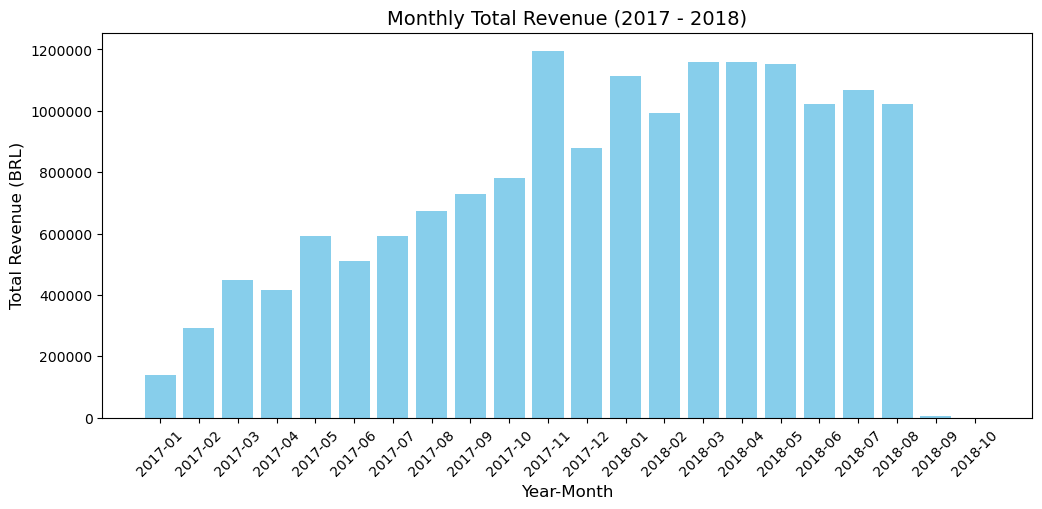

In [12]:
print(f"Sample Size for RQ1 (All orders): N = {len(order_master)}")

# Keep only 2017 and 2018 data for a clean chart
sales_17_18 = order_master[order_master['order_month'].str.startswith(('2017', '2018'), na=False)]

# Calculate total revenue per month
monthly_revenue = sales_17_18.groupby('order_month')['total_payment'].sum().reset_index()

# Plot the bar chart
plt.figure(figsize=(12, 5))
plt.bar(monthly_revenue['order_month'], monthly_revenue['total_payment'], color='skyblue')
plt.title('Monthly Total Revenue (2017 - 2018)', fontsize=14)
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.xticks(rotation=45)
plt.ticklabel_format(style='plain', axis='y') # Disable scientific notation (e.g., 1e6)
plt.show()

### Conclusion: Monthly Revenue Trends (RQ1)

Based on the time-series analysis of **99,441 orders**, here is the business insight:

* **Massive Growth:** The platform showed consistent revenue growth throughout 2017, maintaining strong sales into the first half of 2018.
* **Peak Seasonality:** November 2017 was the highest-grossing month by far, highlighting the massive impact of Black Friday and holiday shopping. *(Note: The drop in Sep 2018 indicates the end of the dataset's timeframe, not a drop in actual sales).*
* **Business Action:** Olist must scale up its server capacity, logistics network, and customer support specifically (especially November) to maximize profits and handle peak holiday demand smoothly.

### RQ2: Delivery Delay and Customer Satisfaction
**Methodology Justification:** I am using the **Spearman Rank-Order Correlation** test instead of Pearson. This is because my dependent variable (`review_score`) is an ordinal category (1 to 5 stars), and delivery delays do not follow a normal distribution. Spearman is the mathematically robust choice here.

In [13]:
# To test this, I must drop rows where the order hasn't been delivered or has no review
clean_data_rq2 = order_master.dropna(subset=['delivery_delay_days', 'review_score'])

# Report the exact sample size after cleaning
print(f"Sample Size for RQ2 (Completed orders only): N = {len(clean_data_rq2)}")

# Run the Spearman correlation test
correlation, p_value = spearmanr(clean_data_rq2['delivery_delay_days'], clean_data_rq2['review_score'])

print(f"Spearman Correlation: {correlation:.4f}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: The p-value is less than 0.05. There is a statistically significant negative association between delays and customer satisfaction.")

Sample Size for RQ2 (Completed orders only): N = 95830
Spearman Correlation: -0.1761
P-value: 0.0000e+00
Conclusion: The p-value is less than 0.05. There is a statistically significant negative association between delays and customer satisfaction.


In [14]:
from IPython.display import display

conclusion = "Statistically significant negative association" if p_value < 0.05 else "No statistically significant association"

result_df = pd.DataFrame({
    "Metric": ["Sample Size (N)", "Spearman Correlation", "P-value", "Conclusion"],
    "Result": [len(clean_data_rq2), round(correlation, 4), f"{p_value:.4e}", conclusion]
})

display(result_df)


,Metric,Result
0,Sample Size (N),95830
1,Spearman Correlation,-0.1761
2,P-value,0.0000e+00
3,Conclusion,Statistically significant negative association


### Conclusion: Delivery Delay vs. Customer Satisfaction

Based on our test of **95,830 orders**, here is the final result:

* **The Math (Correlation: -0.176):** As delivery delays increase, customer review scores drop.
* **The Proof (P-value: 0.0000):** This result is statistically proven and is not random chance.
* **Business Action:** Late shipping directly hurts Olist's brand. Reducing delivery times must be a top priority to improve customer satisfaction.

### RQ3: State-Level Comparisons
Finally, I will look at the geographical data to see which 5 Brazilian states generate the highest total revenue for the company.

Sample Size for RQ3: N = 99441


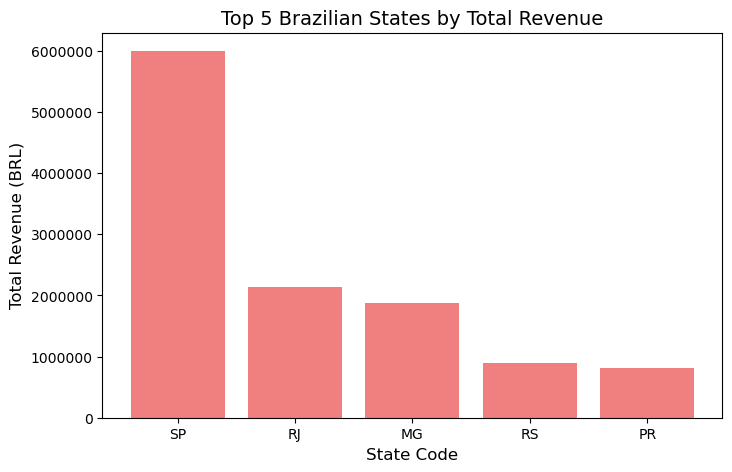

In [15]:
print(f"Sample Size for RQ3: N = {len(order_master)}")

# Group data by Customer State and sum the revenue
state_revenue = order_master.groupby('customer_state')['total_payment'].sum().reset_index()

# Sort the values to find the top 5 states
top_5_states = state_revenue.sort_values(by='total_payment', ascending=False).head(5)

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(top_5_states['customer_state'], top_5_states['total_payment'], color='lightcoral')
plt.title('Top 5 Brazilian States by Total Revenue', fontsize=14)
plt.xlabel('State Code', fontsize=12)
plt.ylabel('Total Revenue (BRL)', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Conclusion: Top Revenue-Generating States (RQ3)

Based on the geographic analysis of **99,441 orders**, here is the business insight:

* **The Market Leader:** São Paulo (SP) completely dominates the platform, generating nearly 3 times more revenue than the second-highest state (RJ).
* **The Core Region:** The Southeast region (SP, RJ, MG) drives the vast majority of Olist's total sales.
* **Business Action:** Olist must prioritize its logistics and warehouse networks in São Paulo to satisfy its biggest customer base, while using targeted marketing to grow the market in other states.

##  Advanced Business Analysis: Customer Segmentation (RFM)

To provide deeper business value and actionable insights, we will conduct an **RFM (Recency, Frequency, Monetary)** analysis. This is a proven marketing model used to evaluate customer behavior and identify VIP segments.

* **Recency (R):** How recently did the customer make a purchase? (Measured in days since their last order).
* **Frequency (F):** How often do they buy? (Total number of orders).
* **Monetary (M):** How much do they spend? (Total revenue generated by the customer).

By aggregating our `order_master` dataset at the `customer_id` level, we can identify our most valuable customers and understand the general distribution of spending on the Olist platform.

In [16]:
# Convert 'order_purchase_timestamp' to actual datetime format
order_master['order_purchase_timestamp'] = pd.to_datetime(order_master['order_purchase_timestamp'])
print("Date conversion successful!")

Date conversion successful!


In [17]:
# Set the snapshot date (1 day after the very last order in our dataset)
snapshot_date = order_master['order_purchase_timestamp'].max() + dt.timedelta(days=1)

print(f"Our snapshot date for calculation is: {snapshot_date}")

Our snapshot date for calculation is: 2018-10-18 17:30:18


In [18]:
# Calculate R (Recency), F (Frequency), and M (Monetary Value) for each customer
rfm = order_master.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'count',                                                  # Frequency
    'total_payment': 'sum'                                                # Monetary
}).reset_index()

print("RFM table created successfully!")

RFM table created successfully!


In [19]:
top_customers = rfm.sort_values(by='total_payment', ascending=False).head(5)
print("\n🏆 Top 5 VIP Customers (by Total Spent):")
display(top_customers)


🏆 Top 5 VIP Customers (by Total Spent):


,customer_id,order_purchase_timestamp,order_id,total_payment
8546,1617b1357756262bfa56ab541c47bc16,384,1,13664.08
91985,ec5b2ba62e574342386871631fafd3fc,95,1,7274.88
77522,c6e2731c5b391845f6800c97401a43a9,612,1,6929.31
95124,f48d464a0baaea338cb25f816991ab1f,84,1,6922.21
24771,3fd6777bbce08a352fddd04e4a7cc8f6,511,1,6726.66


/Users/Fatemeh/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


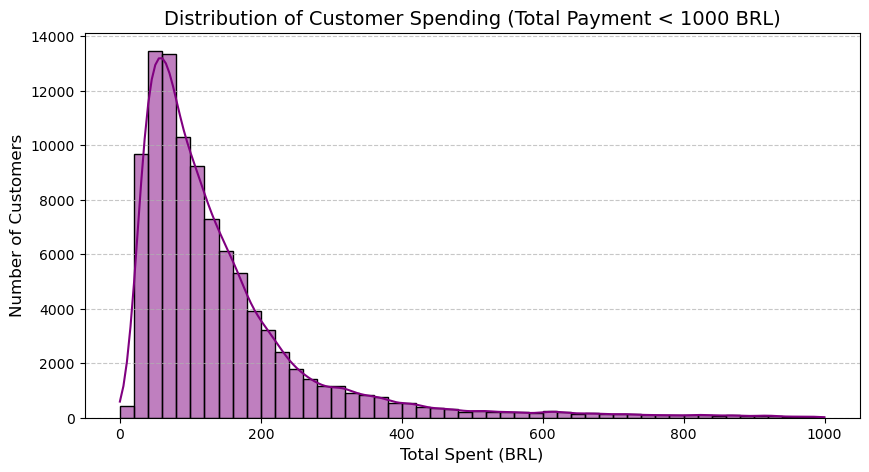

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(rfm[rfm['total_payment'] < 1000]['total_payment'], bins=50, color='purple', kde=True)

plt.title('Distribution of Customer Spending (Total Payment < 1000 BRL)', fontsize=14)
plt.xlabel('Total Spent (BRL)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Conclusion: Customer Spending Distribution (RFM)

Based on the Monetary Value analysis, here is the business insight:

* **The Average Buyer:** The vast majority of Olist customers make smaller purchases, typically spending between **50 and 150 BRL** per order.
* **The VIP Tail:** The distribution is highly right-skewed, showing a small but highly valuable group of VIP customers who spend significantly more.
* **Business Action:** Olist should implement targeted "upselling" (e.g., bundle discounts, free shipping thresholds) to push average buyers to spend slightly more, while creating a loyalty program to retain the high-spending VIPs.

## 5. Predictive Modeling: Predict Customer Satisfaction with Imbalance Handling (SMOTE)

**Goal:** train and evaluate a predictive model of customer satisfaction using engineered features such as delivery performance (`late_days`, `early_days`), spend (`total_payment`), location (`customer_state`), and customer behavior (RFM: Recency/Frequency/Monetary).


In [21]:
# If needed, install imbalanced-learn (for SMOTE)
try:
    import imblearn  # noqa: F401
except Exception:
    print("Installing imbalanced-learn...")
    %pip -q install imbalanced-learn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

In [22]:
# Build a model-ready table

# 1) Start from order-level data (more samples), keep only rows with labels
ml_df = order_master.copy()
ml_df = ml_df[ml_df['order_status'].eq('delivered')].copy()
ml_df = ml_df.dropna(subset=['review_score']).copy()  # label must exist

# 2) Create binary target
ml_df['satisfied'] = (ml_df['review_score'] >= 4).astype(int)

# 3) Keep/select features
# Note: late_days / early_days were created in Feature Engineering.
feature_cols = [
    'late_days',
    'early_days',
    'total_payment',
    'customer_state',
    'customer_id',
]
ml_df = ml_df[feature_cols + ['satisfied']].copy()

# Basic sanity checks
print('Modeling rows:', len(ml_df))
print('Class balance (satisfied=1):', ml_df['satisfied'].mean().round(4))
print(ml_df['satisfied'].value_counts())

Modeling rows: 95832
Class balance (satisfied=1): 0.7892
satisfied
1    75626
0    20206
Name: count, dtype: int64


In [23]:
# 4) Merge in RFM features (customer-level) for the same customers
rfm_features = rfm.rename(columns={
    'order_purchase_timestamp': 'recency_days',
    'order_id': 'frequency_orders',
    'total_payment': 'monetary_total'
}).copy()

ml_df = ml_df.merge(rfm_features[['customer_id', 'recency_days', 'frequency_orders', 'monetary_total']], on='customer_id', how='left')

# Drop customer_id after merge (identifier, not a feature)
ml_df = ml_df.drop(columns=['customer_id'])
print('After RFM merge, missing RFM rows:', ml_df[['recency_days','frequency_orders','monetary_total']].isna().any(axis=1).sum())
ml_df.head()

After RFM merge, missing RFM rows: 0


,late_days,early_days,total_payment,customer_state,satisfied,recency_days,frequency_orders,monetary_total
0,0.0,8.0,38.71,SP,1,381,1,38.71
1,0.0,6.0,141.46,BA,1,85,1,141.46
2,0.0,18.0,179.12,GO,1,71,1,179.12
3,0.0,13.0,72.20,RN,1,333,1,72.20
4,0.0,10.0,28.62,SP,1,246,1,28.62


In [24]:
# Train / test split + SMOTE
X = ml_df.drop(columns=['satisfied'])
y = ml_df['satisfied']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

num_features = ['late_days', 'early_days', 'total_payment', 'recency_days', 'frequency_orders', 'monetary_total']
cat_features = ['customer_state']

numeric_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_features),
        ('cat', categorical_pipe, cat_features)
    ],
    remainder='drop'
)
# Logistic Regression baseline (strong, interpretable)
clf = LogisticRegression(max_iter=2000, class_weight=None)

model = ImbPipeline(steps=[
    ('preprocess', preprocess),
    ('smote', SMOTE(random_state=42)),
    ('clf', clf)
])

model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['late_days', 'early_days',
                                                   'total_payment',
                                                   'recency_days',
                                                   'frequency_orders',
                                                   'monetary_total']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['customer_state'])])),
                ('smote', SMOTE(random_state=42)),
                ('clf', LogisticRegression(max_iter=2000))])

In [25]:
# Fit + evaluate
model.fit(X_train, y_train)

proba = model.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)

print('Confusion matrix:\n', confusion_matrix(y_test, pred))

import pandas as pd
from IPython.display import display

report_df = pd.DataFrame(
    classification_report(y_test, pred, output_dict=True)
).transpose().round(3)

print('\nClassification report:')
display(report_df)

roc = roc_auc_score(y_test, proba)
pr_auc = average_precision_score(y_test, proba)
print(f'ROC-AUC: {roc:.4f}')
print(f'PR-AUC : {pr_auc:.4f}')

# Baseline: always predict majority class
majority = int(y_train.mean() >= 0.5)
baseline_pred = np.full_like(y_test, fill_value=majority)
print('\nBaseline confusion matrix (majority class):\n', confusion_matrix(y_test, baseline_pred))

Confusion matrix:
 [[ 1486  2555]
 [ 2302 12824]]

Classification report:


,precision,recall,f1-score,support
0,0.392,0.368,0.380,4041.000
1,0.834,0.848,0.841,15126.000
accuracy,0.747,0.747,0.747,0.747
macro avg,0.613,0.608,0.610,19167.000
weighted avg,0.741,0.747,0.744,19167.000


ROC-AUC: 0.6403
PR-AUC : 0.8410

Baseline confusion matrix (majority class):
 [[    0  4041]
 [    0 15126]]


In [26]:
y.value_counts()

satisfied
1    75626
0    20206
Name: count, dtype: int64

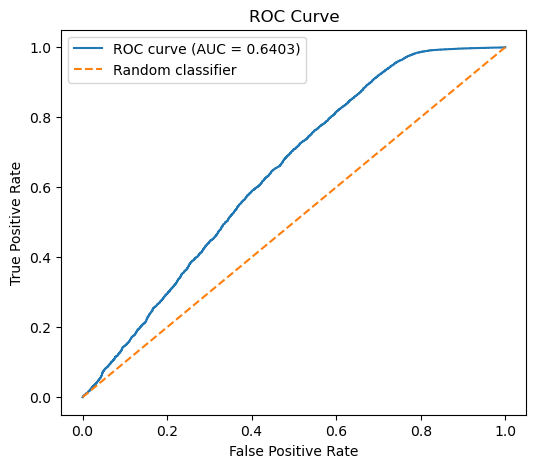

In [27]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The ROC curve lies above the random-classifier line, showing that the model performs better than chance. The ROC-AUC of 0.6403 indicates fair but not strong classification performance. This means the model has some ability to separate the classes, but there is considerable room for improvement.


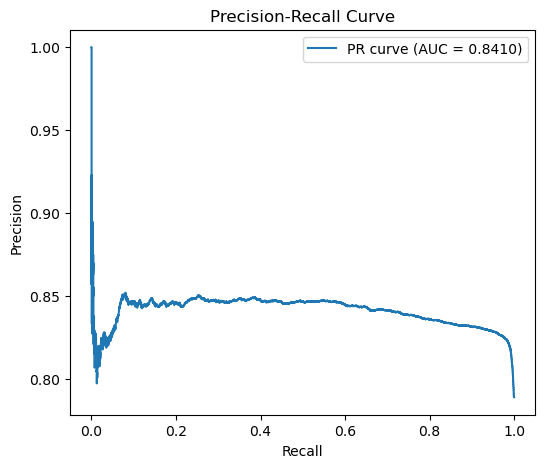

In [28]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR curve (AUC = {pr_auc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

The Precision–Recall curve indicates that the model has good performance in identifying the positive class. The PR-AUC of 0.8410 suggests strong precision–recall tradeoff, with precision remaining relatively stable around 0.83–0.85 across much of the recall range. This means the model is fairly effective at detecting positive cases while keeping false positives at a moderate level.

In [29]:
# FINAL STEP: Preparing Data for Power BI
order_master.to_csv('olist_final_report_data.csv', index=False)

print("✅ Success! The file 'olist_final_report_data.csv' is now saved in your Mac folder.")

✅ Success! The file 'olist_final_report_data.csv' is now saved in your Mac folder.


In [31]:
df = order_master.copy()

In [33]:
import pandas as pd
import numpy as np

df = order_master.copy()

# 1) Make sure date is datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')

# 2) Year-Month for time visuals
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# 3) Late flag for late delivery rate (0/1)
df['is_late'] = (df['late_days'] > 0).astype(int)

# 4) Late days (late only) so its average is meaningful (NaN ignored in averages)
df['late_days_lateonly'] = np.where(df['late_days'] > 0, df['late_days'], np.nan)

# 5) Delay buckets for the best satisfaction visual
df['late_bucket'] = pd.cut(
    df['late_days'].fillna(0),   # avoid errors if NaN exists
    bins=[-0.1, 0, 2, 5, 10, 10**9],
    labels=['On time', 'Late 1–2', 'Late 3–5', 'Late 6–10', 'Late >10']
)

# Save for Power BI (use THIS file for visuals)
df.to_csv('olist_final_report_data_no_dax.csv', index=False)

print("✅ Saved: olist_final_report_data_no_dax.csv")

✅ Saved: olist_final_report_data_no_dax.csv
